# Phase 1 — KWIC validation

Visual and summary diagnostics for the Phase 1 KWIC extraction
(`ph-project-5f9.5`). Reads the 9 sidecar `.report.json` files and the 9 CSVs
produced by `scripts/extract_kwic.py` and answers three questions:

1. **Did we hit the 200-per-term target?** — global summary + per-(lang × domain) bar charts.
2. **Where did we fall short?** — sorted listing of every under-target term.
3. **Do the sentences look right?** — random sample inspection per pair.

This notebook is for human inspection; it writes nothing to disk.


## May 2026 scope pivot — color domain only

As of 2026-05-04 the COSI 115a final analysis is **scoped to the COLOR domain only**.
Emotion and kinship canon-term lists remain in `canon-terms/` for potential follow-up
work after the May 6 deadline but are not analyzed in this study.

See `CLAUDE.md` → "Current scope (May 2026)" for the full rationale.
`DOMAINS` in the cell below is set to `['color']` accordingly.

This notebook was regenerated after the multi-year corpus rescue (`ph-project-i6q`):
color KWIC is now extracted from three Leipzig 1M news corpora per language
(years 2019, 2020, 2023), giving ~3M sentences per language instead of the original 1M.
Each row's `corpus_source` reflects its originating year corpus;
the sidecar `corpus_source` field is a list of all input corpus IDs.

**`фиолетовый` is kept under-target.** After this rescue the only residual is
Russian `фиолетовый` at n=104 (vs. the n≥150 acceptance threshold). It is kept
rather than dropped because it is a Berlin & Kay basic color term and n=104 is
sufficient to compute an mBERT attention graph — downstream PH features for this
term may be noisier than for the saturated (n=200) terms. See `bd ph-project-bcy`.


In [1]:
# Ensure the repo root (parent of notebooks/) is on sys.path so absolute imports
# resolve regardless of how the kernel was launched.
import sys
import pathlib

_NOTEBOOK_DIR = pathlib.Path(__file__).resolve().parent if '__file__' in dir() else pathlib.Path('.').resolve()
_REPO_ROOT = _NOTEBOOK_DIR.parent if _NOTEBOOK_DIR.name == 'notebooks' else _NOTEBOOK_DIR

if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import json
import random

import matplotlib.pyplot as plt
import pandas as pd

print(f'Repo root: {_REPO_ROOT}')


Repo root: /home/anna/ph-project


In [2]:
DATA_DIR = _REPO_ROOT / 'data' / 'kwic'
LANGS = ['en', 'ru', 'es']
DOMAINS = ['color']  # May 2026 scope: color domain only (see CLAUDE.md)
N_SAMPLES_TARGET = 200
INSPECTION_SEED = 0

print(f'Data dir: {DATA_DIR}')
print(f'Langs:    {LANGS}')
print(f'Domains:  {DOMAINS}')


Data dir: /home/anna/ph-project/data/kwic
Langs:    ['en', 'ru', 'es']
Domains:  ['color']


## Step 1 — Load all 9 sidecar reports

Each `<lang>/<domain>.report.json` records per-term `n_corpus_hits`,
`n_kept_after_dedup`, `n_emitted`, and `under_target` (see
`data/kwic/SCHEMA.md`). Load them into a `(lang, domain) -> report` dict.


In [3]:
reports = {}
for lang in LANGS:
    for domain in DOMAINS:
        report_path = DATA_DIR / lang / f'{domain}.report.json'
        with report_path.open(encoding='utf-8') as fh:
            reports[(lang, domain)] = json.load(fh)
        report = reports[(lang, domain)]
        n_terms = len(report['terms'])
        n_under = sum(1 for t in report['terms'] if t['under_target'])
        print(f'  {lang}/{domain}: {n_terms} terms, {n_under} under-target, '
              f'corpus_total_sentences={report["corpus_total_sentences"]:,}')


  en/color: 11 terms, 0 under-target, corpus_total_sentences=3,000,000
  ru/color: 12 terms, 2 under-target, corpus_total_sentences=3,000,000
  es/color: 11 terms, 1 under-target, corpus_total_sentences=3,000,000


## Step 2 — Global summary table

One row per `(language, domain)`. `mean_n_emitted` close to 200 means the
extraction comfortably hit the target for that pair; values much below 200
mean many terms are sparse in this corpus.


In [4]:
summary_rows = []
for lang in LANGS:
    for domain in DOMAINS:
        report = reports[(lang, domain)]
        terms = report['terms']
        n_terms = len(terms)
        n_under_target = sum(1 for t in terms if t['under_target'])
        n_emitted_list = [t['n_emitted'] for t in terms]
        mean_n_emitted = sum(n_emitted_list) / n_terms if n_terms else 0.0
        total_rows = sum(n_emitted_list)
        summary_rows.append({
            'language': lang,
            'domain': domain,
            'n_terms': n_terms,
            'n_under_target': n_under_target,
            'mean_n_emitted': round(mean_n_emitted, 1),
            'total_rows': total_rows,
        })

summary_df = pd.DataFrame(summary_rows)
grand_total = int(summary_df['total_rows'].sum())
print(f'Grand total KWIC rows across all 9 (lang × domain): {grand_total:,}')
print(f'(target ceiling: 9 × n_terms × 200; floor: sum of corpus hits)')
summary_df


Grand total KWIC rows across all 9 (lang × domain): 6,628
(target ceiling: 9 × n_terms × 200; floor: sum of corpus hits)


,language,domain,n_terms,n_under_target,mean_n_emitted,total_rows
0,en,color,11,0,200.0,2200
1,ru,color,12,2,188.9,2267
2,es,color,11,1,196.5,2161


## Step 3 — Per-(lang × domain) hit-count distributions

For each pair, plot `n_emitted` per term sorted descending. Bars at exactly
200 mean the term hit the cap and was downsampled. Bars below 200 are flagged
red — those are under-target. The black dashed line marks the 200 target.


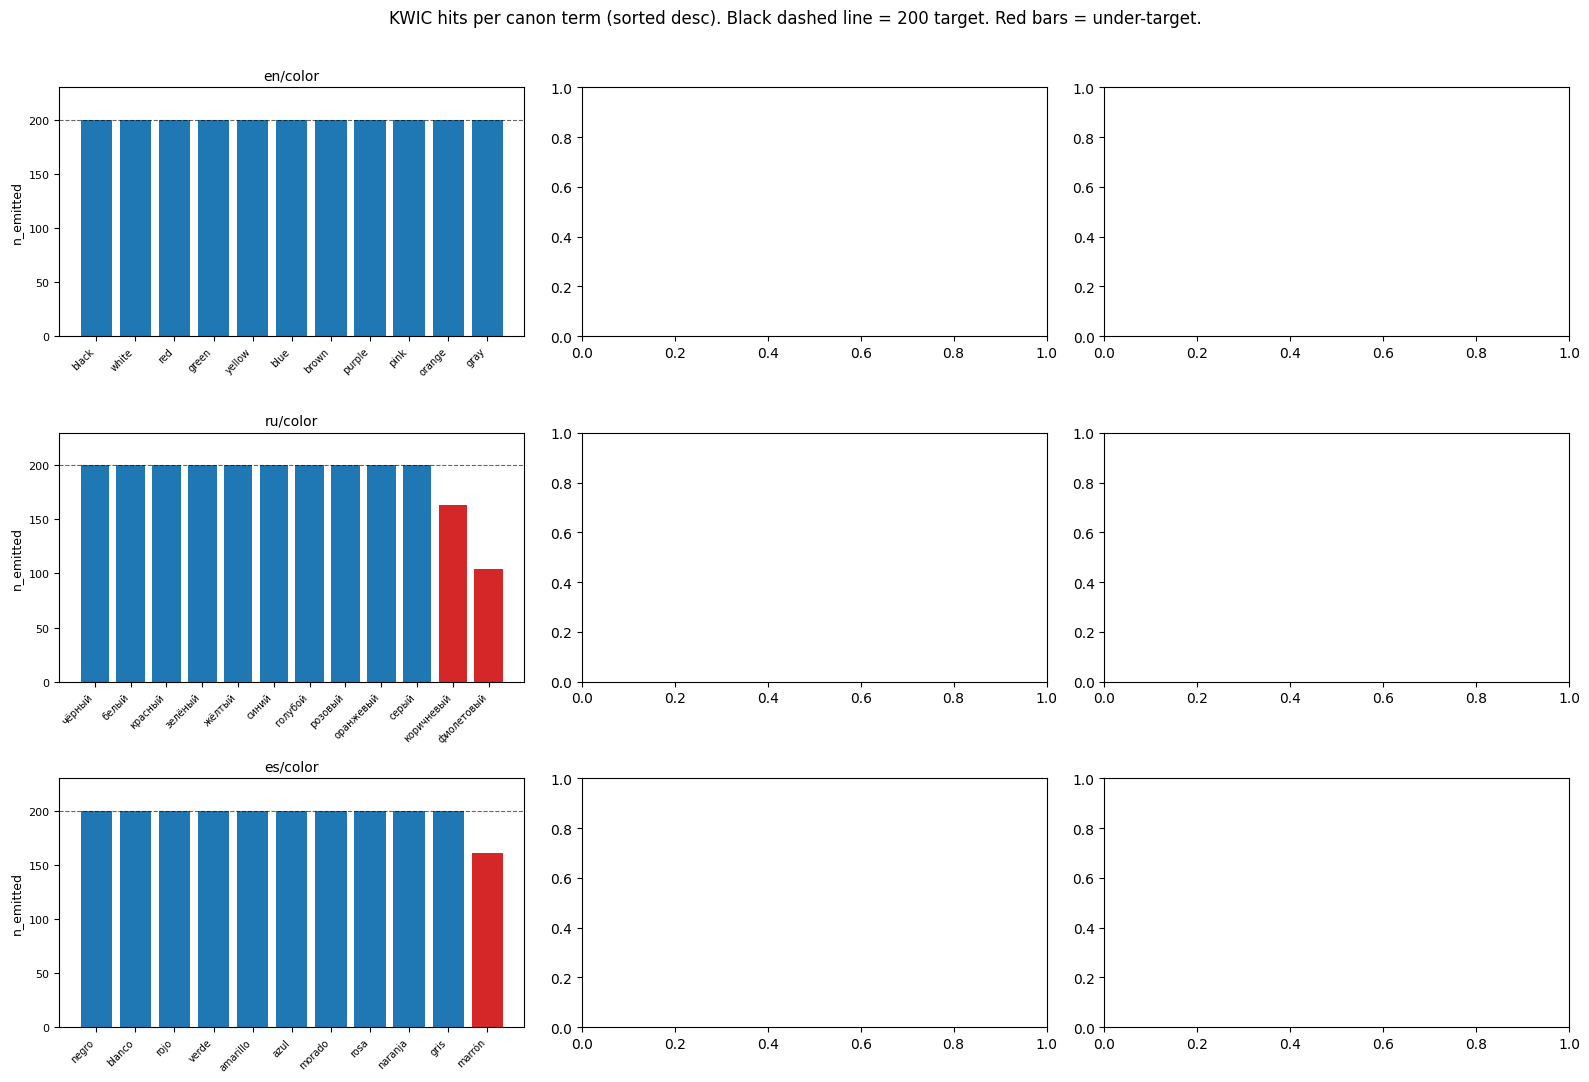

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
fig.suptitle(
    'KWIC hits per canon term (sorted desc). Black dashed line = 200 target. '
    'Red bars = under-target.',
    fontsize=12,
)

for row, lang in enumerate(LANGS):
    for col, domain in enumerate(DOMAINS):
        ax = axes[row, col]
        terms = reports[(lang, domain)]['terms']
        sorted_terms = sorted(terms, key=lambda t: t['n_emitted'], reverse=True)
        n_emitted = [t['n_emitted'] for t in sorted_terms]
        labels = [t['term'] for t in sorted_terms]
        bar_colors = [
            '#d62728' if t['under_target'] else '#1f77b4'
            for t in sorted_terms
        ]

        x = list(range(len(sorted_terms)))
        ax.bar(x, n_emitted, color=bar_colors)
        ax.axhline(N_SAMPLES_TARGET, linestyle='--', color='black',
                   alpha=0.6, linewidth=0.8)
        ax.set_title(f'{lang}/{domain}', fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
        ax.tick_params(axis='y', labelsize=8)
        if n_emitted:
            ax.set_ylim(0, max(N_SAMPLES_TARGET + 30, max(n_emitted) + 30))
        else:
            ax.set_ylim(0, N_SAMPLES_TARGET + 30)
        if col == 0:
            ax.set_ylabel('n_emitted', fontsize=9)

fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


## Step 4 — Under-target term listing

Every term flagged `under_target=True`, sorted by `n_corpus_hits` ascending
(rarest first). This is the "do we have enough data?" diagnostic — terms
with very low corpus counts may need a larger corpus or a genre-broadening
pass.


In [6]:
under_target_rows = []
for lang in LANGS:
    for domain in DOMAINS:
        for t in reports[(lang, domain)]['terms']:
            if t['under_target']:
                under_target_rows.append({
                    'language': lang,
                    'domain': domain,
                    'term': t['term'],
                    'n_corpus_hits': t['n_corpus_hits'],
                    'n_kept_after_dedup': t['n_kept_after_dedup'],
                    'n_emitted': t['n_emitted'],
                })

if under_target_rows:
    under_df = (
        pd.DataFrame(under_target_rows)
          .sort_values('n_corpus_hits', ascending=True)
          .reset_index(drop=True)
    )
    print(f'{len(under_df)} under-target terms total\n')
    print(under_df.to_string(index=False))
else:
    print('No under-target terms — every (lang × domain) hit 200 across all canon terms.')


3 under-target terms total

language domain       term  n_corpus_hits  n_kept_after_dedup  n_emitted
      ru  color фиолетовый            104                 104        104
      es  color     marrón            161                 161        161
      ru  color коричневый            163                 163        163


## Step 5 — Random sample inspection

For each `(lang, domain)`, draw 3 canon terms uniformly at random and 3 KWIC
sentences for each, deterministically (`INSPECTION_SEED = 0`). The point is
human-readability: do the windows look like sentences a human would expect
the canon term to appear in?


In [7]:
term_rng = random.Random(INSPECTION_SEED)
sentence_rng_seed = INSPECTION_SEED

for lang in LANGS:
    for domain in DOMAINS:
        csv_path = DATA_DIR / lang / f'{domain}.csv'
        df = pd.read_csv(csv_path, encoding='utf-8')
        terms_present = sorted(df['term'].unique())

        sample_size = min(3, len(terms_present))
        chosen_terms = term_rng.sample(terms_present, sample_size)

        corpus_source = reports[(lang, domain)]["corpus_source"]
        # corpus_source is now a list for multi-year extractions
        if isinstance(corpus_source, list):
            corpus_label = ', '.join(corpus_source)
        else:
            corpus_label = corpus_source
        print(f'\n=== {lang}/{domain} (corpus={corpus_label}) ===')
        for term in chosen_terms:
            term_df = df[df['term'] == term]
            n_avail = len(term_df)
            n_show = min(3, n_avail)
            sample_df = term_df.sample(n=n_show, random_state=sentence_rng_seed)
            print(f'\n  [{term}]  (showing {n_show} of {n_avail} emitted)')
            for _, row in sample_df.iterrows():
                print(f'    {row["sentence"]}')



=== en/color (corpus=eng_news_2019_1M, eng_news_2020_1M, eng_news_2023_1M) ===

  [pink]  (showing 3 of 200 emitted)
    Sisu the dragon, a white dragon with a blue and pink tail, not looking anything like the way dragons have traditionally
    The range also includes pink and blue bottoms to complete the set along with white
    Brittany used barbells, dumbbells, and a pink kettlebell during an upper body workout.

  [yellow]  (showing 3 of 200 emitted)
    Throughout the Naruto series, the yellow-haired ninja is seen as its most extensive user, even managing
    bright yellow ex-AA van on the top of a huge yellow AA lorry, so you can’t exactly miss it!
    A yellow thunderstorm warning – highlighting potential disruption to travel, power cuts

  [black]  (showing 3 of 200 emitted)
    Coco Rocha took to the rose-lined runway wearing a black-and-white printed pantsuit featuring dramatic ruffle sleeves, and accessorized with an
    Black limousines pass in front of Trump Tower on Fift

## Step 6 — Discussion notes

A healthy 5f9.5 run:

* `mean_n_emitted` close to 200 for color and emotion across all three
  languages (these vocabularies are well-attested in news text).
* Kinship is the most likely under-target domain — affinal relations
  (in-laws) and grandparental terms are rarer in news than in conversation.
  Russian kinship in particular has fine-grained affinal terms (e.g.,
  свёкор, золовка, шурин) that are rare even in large corpora.
* `total_rows` summed across all 9 pairs in the 30,000-37,000 range is
  in the expected ceiling (≈ 9 × ~20 terms × 200 = 36,000).

If a single (lang, domain) shows 5 or more under-target terms, file a
discovered-from issue against `ph-project-5f9.5` to investigate either:

* the canon list (some literature-attested terms genuinely don't appear
  in 2020 news), or
* the corpus genre (we may need an additional non-news corpus for that
  language/domain), or
* expanding to 3M (Leipzig has 3M sentence dumps for the major languages).
